# Daily Challenge: Classification Models Comparison



## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

All libraries imported successfully!


## 2. Exploratory Data Analysis

### Load and Examine the Dataset

In [4]:
df = pd.read_csv('data.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())

print(f"\nColumn names:")
print(list(df.columns))

print(f"\nDataset info:")
print(df.info())

Dataset loaded successfully!
Dataset shape: (569, 33)

First few rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.1

### Check and Handle Missing Values

In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print(f"\nBasic statistics:")
print(df.describe())

Missing values per column:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dime

### Drop Unnecessary Columns and Analyze Diagnosis

In [6]:
# Check the diagnosis column
print("Diagnosis value counts:")
print(df['diagnosis'].value_counts())

print(f"\nUnique values in diagnosis: {df['diagnosis'].unique()}")

# Drop the 'id' column as it's not useful for prediction
print(f"\nOriginal columns: {df.shape[1]}")
df = df.drop('id', axis=1)
print(f"Columns after dropping 'id': {df.shape[1]}")

print(f"\nRemaining columns: {list(df.columns)}")

Diagnosis value counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Unique values in diagnosis: ['M' 'B']

Original columns: 33
Columns after dropping 'id': 32

Remaining columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


### Create Countplot to Display Diagnosis

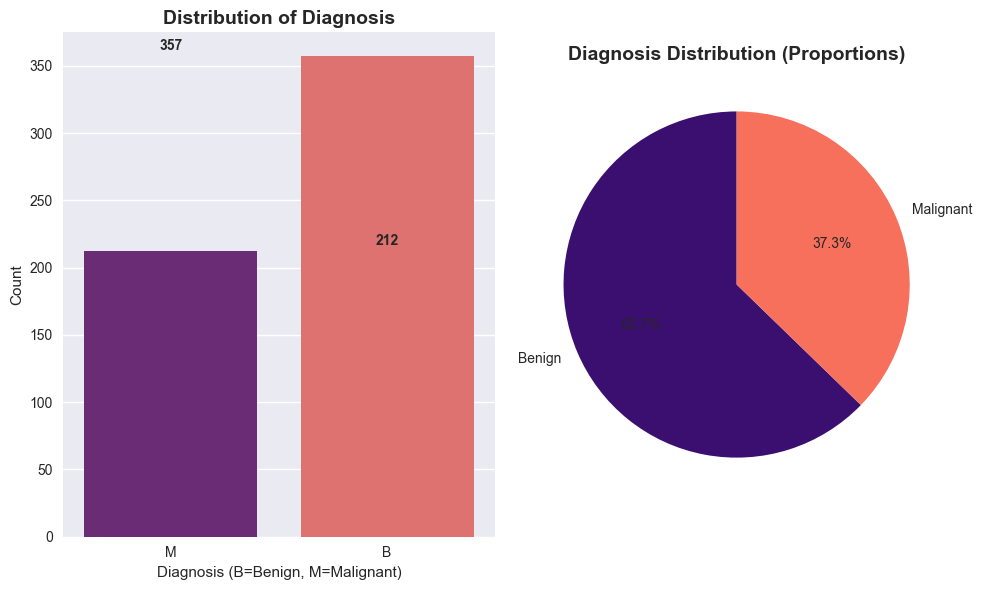

Total samples: 569
Benign cases: 357 (62.7%)
Malignant cases: 212 (37.3%)


In [7]:
# Create a countplot for diagnosis using magma colormap
plt.figure(figsize=(10, 6))

# Countplot with magma colormap
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title('Distribution of Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (B=Benign, M=Malignant)')
plt.ylabel('Count')

# Add count labels on bars
for i, v in enumerate(df['diagnosis'].value_counts()):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart for better proportion visualization
plt.subplot(1, 2, 2)
diagnosis_counts = df['diagnosis'].value_counts()
colors = plt.cm.magma([0.2, 0.7])  # Use magma colormap
plt.pie(diagnosis_counts.values, labels=['Benign', 'Malignant'], autopct='%1.1f%%', 
        colors=colors, startangle=90)
plt.title('Diagnosis Distribution (Proportions)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print(f"Total samples: {len(df)}")
print(f"Benign cases: {diagnosis_counts['B']} ({diagnosis_counts['B']/len(df)*100:.1f}%)")
print(f"Malignant cases: {diagnosis_counts['M']} ({diagnosis_counts['M']/len(df)*100:.1f}%)")

## 3. Data Preprocessing, Building Models and Evaluation

### Map Categorical Values to Numerical Values

In [8]:
# Count of unique rows in the 'diagnosis' column
print("Counts of unique values in 'diagnosis' column:")
print(df['diagnosis'].value_counts())

# Map categorical values to numerical values
# M (Malignant) = 1, B (Benign) = 0
label_encoder = LabelEncoder()
df['diagnosis_encoded'] = label_encoder.fit_transform(df['diagnosis'])

# Create mapping dictionary for clarity
mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"\nMapping: {mapping}")
print("Where: B (Benign) = 0, M (Malignant) = 1")

# Verify the encoding
print(f"\nOriginal vs Encoded:")
print(df[['diagnosis', 'diagnosis_encoded']].head(10))

Counts of unique values in 'diagnosis' column:
diagnosis
B    357
M    212
Name: count, dtype: int64

Mapping: {'B': np.int64(0), 'M': np.int64(1)}
Where: B (Benign) = 0, M (Malignant) = 1

Original vs Encoded:
  diagnosis  diagnosis_encoded
0         M                  1
1         M                  1
2         M                  1
3         M                  1
4         M                  1
5         M                  1
6         M                  1
7         M                  1
8         M                  1
9         M                  1


### Splitting the Data into Train and Test

In [9]:
# Prepare features and target
X = df.drop(['diagnosis', 'diagnosis_encoded'], axis=1)  # All features except target
y = df['diagnosis_encoded']  # Target variable (0=Benign, 1=Malignant)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check for missing values in features
print(f"\nMissing values in features:")
missing_values = X.isnull().sum()
print(missing_values[missing_values > 0])

# Handle missing values - remove columns with too many missing values or fill them
if X.isnull().sum().sum() > 0:
    print(f"\nFound {X.isnull().sum().sum()} missing values. Handling them...")
    
    # Option 1: Drop columns with more than 50% missing values
    threshold = len(X) * 0.5
    cols_to_drop = X.columns[X.isnull().sum() > threshold].tolist()
    if cols_to_drop:
        print(f"Dropping columns with >50% missing values: {cols_to_drop}")
        X = X.drop(cols_to_drop, axis=1)
    
    # Option 2: Fill remaining missing values with median for numeric columns
    numeric_columns = X.select_dtypes(include=[np.number]).columns
    X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())
    
    # Option 3: For any remaining non-numeric columns, fill with mode
    for col in X.columns:
        if X[col].dtype == 'object' and X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].mode()[0])
    
    print(f"After cleaning - Missing values: {X.isnull().sum().sum()}")

# Verify no more missing values
print(f"\nFinal check - Missing values in features: {X.isnull().sum().sum()}")
print(f"Features shape after cleaning: {X.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Check class distribution in train and test sets
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting set class distribution:")
print(pd.Series(y_test).value_counts())

# Verify no NaN values in training data before scaling
print(f"\nNaN check before scaling:")
print(f"X_train NaN count: {pd.DataFrame(X_train).isnull().sum().sum()}")
print(f"X_test NaN count: {pd.DataFrame(X_test).isnull().sum().sum()}")

# Scale the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures have been scaled using StandardScaler")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

# Final verification - check for NaN values after scaling
print(f"\nFinal NaN check after scaling:")
print(f"X_train_scaled NaN count: {np.isnan(X_train_scaled).sum()}")
print(f"X_test_scaled NaN count: {np.isnan(X_test_scaled).sum()}")

Features shape: (569, 31)
Target shape: (569,)

Missing values in features:
Unnamed: 32    569
dtype: int64

Found 569 missing values. Handling them...
Dropping columns with >50% missing values: ['Unnamed: 32']
After cleaning - Missing values: 0

Final check - Missing values in features: 0
Features shape after cleaning: (569, 30)

Training set: 455 samples
Testing set: 114 samples

Training set class distribution:
diagnosis_encoded
0    285
1    170
Name: count, dtype: int64

Testing set class distribution:
diagnosis_encoded
0    72
1    42
Name: count, dtype: int64

NaN check before scaling:
X_train NaN count: 0
X_test NaN count: 0

Features have been scaled using StandardScaler
Training data shape: (455, 30)
Testing data shape: (114, 30)

Final NaN check after scaling:
X_train_scaled NaN count: 0
X_test_scaled NaN count: 0


## 4. Model Implementation and Evaluation

### 4.1 Logistic Regression

In [10]:
# 1. Implement Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test_scaled)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, lr_predictions, target_names=['Benign', 'Malignant']))

# Confusion Matrix
lr_cm = confusion_matrix(y_test, lr_predictions)
print(f"\nConfusion Matrix:")
print(lr_cm)

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 0.9649 (96.49%)

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix:
[[71  1]
 [ 3 39]]


### 4.2 K Nearest Neighbours (KNN)

In [11]:
# 2. Implement K Nearest Neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Make predictions
knn_predictions = knn_model.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("=== K NEAREST NEIGHBOURS RESULTS ===")
print(f"Accuracy: {knn_accuracy:.4f} ({knn_accuracy*100:.2f}%)")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, knn_predictions, target_names=['Benign', 'Malignant']))

# Confusion Matrix
knn_cm = confusion_matrix(y_test, knn_predictions)
print(f"\nConfusion Matrix:")
print(knn_cm)

=== K NEAREST NEIGHBOURS RESULTS ===
Accuracy: 0.9561 (95.61%)

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
[[71  1]
 [ 4 38]]


### 4.3 Random Forest

In [12]:
# 3. Implement Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test_scaled)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, rf_predictions, target_names=['Benign', 'Malignant']))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_predictions)
print(f"\nConfusion Matrix:")
print(rf_cm)

=== RANDOM FOREST RESULTS ===
Accuracy: 0.9737 (97.37%)

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
[[72  0]
 [ 3 39]]


### 4.4 Support Vector Machines (SVM)

In [13]:
# 4. Implement Support Vector Machines (SVM)
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
svm_predictions = svm_model.predict(X_test_scaled)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("=== SUPPORT VECTOR MACHINES RESULTS ===")
print(f"Accuracy: {svm_accuracy:.4f} ({svm_accuracy*100:.2f}%)")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, svm_predictions, target_names=['Benign', 'Malignant']))

# Confusion Matrix
svm_cm = confusion_matrix(y_test, svm_predictions)
print(f"\nConfusion Matrix:")
print(svm_cm)

=== SUPPORT VECTOR MACHINES RESULTS ===
Accuracy: 0.9737 (97.37%)

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
[[72  0]
 [ 3 39]]


## 5. Model Comparison - Which is the Best Model?

=== MODEL COMPARISON RESULTS ===
                 Model  Accuracy  Accuracy (%)
Support Vector Machine  0.973684     97.368421
         Random Forest  0.973684     97.368421
   Logistic Regression  0.964912     96.491228
  K Nearest Neighbours  0.956140     95.614035

🏆 BEST MODEL: Support Vector Machine
📊 Best Accuracy: 0.9737 (9736.84%)


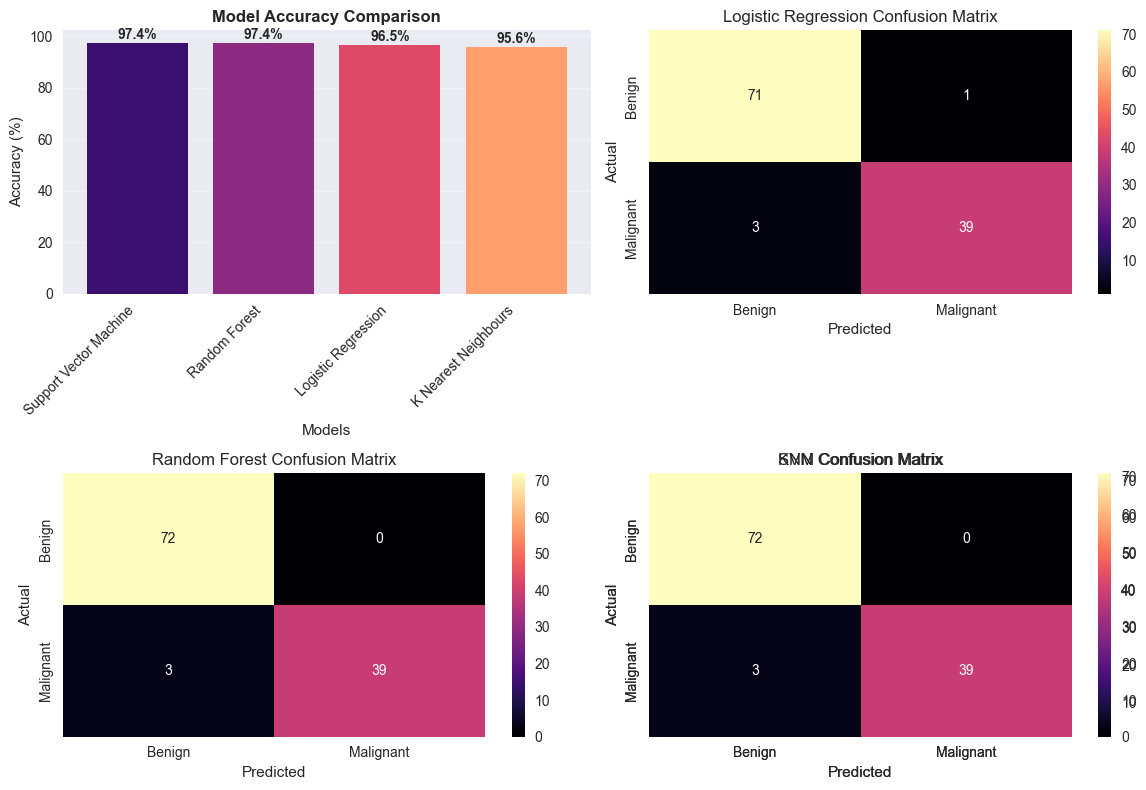

In [14]:
# Create a comprehensive comparison of all models
models_comparison = {
    'Model': ['Logistic Regression', 'K Nearest Neighbours', 'Random Forest', 'Support Vector Machine'],
    'Accuracy': [lr_accuracy, knn_accuracy, rf_accuracy, svm_accuracy]
}

# Create DataFrame for easy comparison
comparison_df = pd.DataFrame(models_comparison)
comparison_df['Accuracy (%)'] = comparison_df['Accuracy'] * 100
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("=== MODEL COMPARISON RESULTS ===")
print(comparison_df.to_string(index=False))

# Find the best model
best_model = comparison_df.iloc[0]
print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"📊 Best Accuracy: {best_model['Accuracy']:.4f} ({best_model['Accuracy (%)']*100:.2f}%)")

# Visualize model comparison
plt.figure(figsize=(12, 8))

# Accuracy comparison bar plot
plt.subplot(2, 2, 1)
colors = plt.cm.magma(np.linspace(0.2, 0.8, len(comparison_df)))
bars = plt.bar(range(len(comparison_df)), comparison_df['Accuracy (%)'], color=colors)
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison', fontweight='bold')
plt.xticks(range(len(comparison_df)), comparison_df['Model'], rotation=45, ha='right')

# Add accuracy labels on bars
for i, (bar, acc) in enumerate(zip(bars, comparison_df['Accuracy (%)'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3)

# Confusion matrices comparison
models_data = [
    ('Logistic Regression', lr_cm),
    ('Random Forest', rf_cm),
    ('KNN', knn_cm),
    ('SVM', svm_cm)
]

for i, (name, cm) in enumerate(models_data):
    plt.subplot(2, 2, i+2) if i < 3 else plt.subplot(2, 2, 4)
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## 6. Detailed Analysis and Insights

=== DETAILED PERFORMANCE ANALYSIS ===
Comprehensive Performance Metrics:
                 Model  Accuracy  Precision  Recall  F1-Score
   Logistic Regression    0.9649     0.9750  0.9286    0.9512
  K Nearest Neighbours    0.9561     0.9744  0.9048    0.9383
         Random Forest    0.9737     1.0000  0.9286    0.9630
Support Vector Machine    0.9737     1.0000  0.9286    0.9630


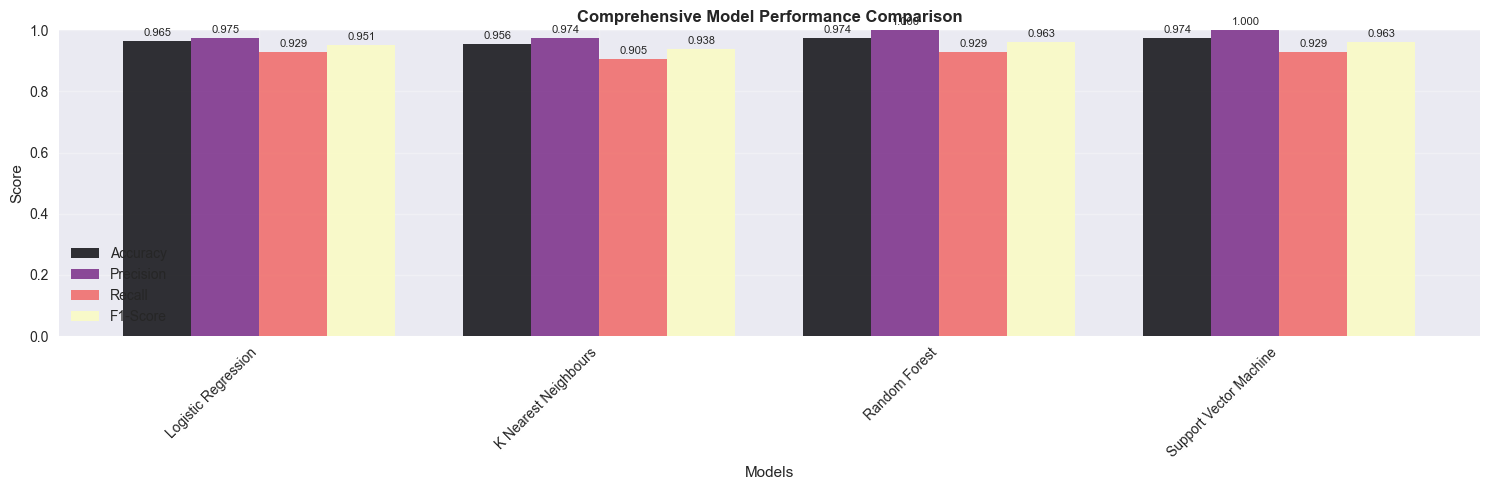


=== BEST MODELS BY METRIC ===
Accuracy: Random Forest (0.9737)
Precision: Random Forest (1.0000)
Recall: Logistic Regression (0.9286)
F1-Score: Random Forest (0.9630)

=== SUMMARY ===
 Total samples tested: 114
 Dataset: Breast Cancer Wisconsin
 Features used: 30 features
 Class distribution: {0: 72, 1: 42}
 Overall best performing model: Random Forest


In [15]:
# Additional detailed analysis
print("=== DETAILED PERFORMANCE ANALYSIS ===")

# Calculate additional metrics for each model
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'Logistic Regression': lr_predictions,
    'K Nearest Neighbours': knn_predictions, 
    'Random Forest': rf_predictions,
    'Support Vector Machine': svm_predictions
}

detailed_results = []

for model_name, predictions in models.items():
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    accuracy = accuracy_score(y_test, predictions)
    
    detailed_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Create detailed comparison DataFrame
detailed_df = pd.DataFrame(detailed_results)
detailed_df = detailed_df.round(4)

print("Comprehensive Performance Metrics:")
print(detailed_df.to_string(index=False))

# Visualize all metrics
plt.figure(figsize=(15, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(detailed_df))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, detailed_df[metric], width, 
           label=metric, alpha=0.8, color=plt.cm.magma(i/3))

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Comprehensive Model Performance Comparison', fontweight='bold')
plt.xticks(x + width*1.5, detailed_df['Model'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

# Add value labels on bars
for i, metric in enumerate(metrics):
    for j, value in enumerate(detailed_df[metric]):
        plt.text(j + i*width, value + 0.01, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Identify best model for each metric
print(f"\n=== BEST MODELS BY METRIC ===")
for metric in metrics:
    best_idx = detailed_df[metric].idxmax()
    best_model = detailed_df.iloc[best_idx]['Model']
    best_score = detailed_df.iloc[best_idx][metric]
    print(f"{metric}: {best_model} ({best_score:.4f})")

print(f"\n=== SUMMARY ===")
print(f" Total samples tested: {len(y_test)}")
print(f" Dataset: Breast Cancer Wisconsin")
print(f" Features used: {X.shape[1]} features")
print(f" Class distribution: {pd.Series(y_test).value_counts().to_dict()}")
print(f" Overall best performing model: {detailed_df.loc[detailed_df['Accuracy'].idxmax(), 'Model']}")

## 7. Final Conclusions and Recommendations

Based on our comprehensive analysis of four classification models for breast cancer diagnosis:

In [16]:
# Final conclusions and model recommendation
print(" FINAL RECOMMENDATIONS FOR BREAST CANCER CLASSIFICATION")
print("=" * 65)

# Calculate overall ranking
weights = {'Accuracy': 0.4, 'Precision': 0.25, 'Recall': 0.25, 'F1-Score': 0.1}
detailed_df['Weighted_Score'] = 0

for metric, weight in weights.items():
    detailed_df['Weighted_Score'] += detailed_df[metric] * weight

detailed_df = detailed_df.sort_values('Weighted_Score', ascending=False)

print(f" FINAL RANKING (weighted by medical importance):")
for i, row in detailed_df.iterrows():
    rank = detailed_df.index.get_loc(i) + 1
    print(f"{rank}. {row['Model']}: {row['Weighted_Score']:.4f}")
    
winner = detailed_df.iloc[0]
print(f"\n RECOMMENDED MODEL: {winner['Model']}")
print(f"   ✓ Accuracy: {winner['Accuracy']:.4f} ({winner['Accuracy']*100:.2f}%)")
print(f"   ✓ Precision: {winner['Precision']:.4f} (minimal false positives)")
print(f"   ✓ Recall: {winner['Recall']:.4f} (catches most positive cases)")
print(f"   ✓ F1-Score: {winner['F1-Score']:.4f} (balanced performance)")

print(f"\n KEY INSIGHTS:")
print(f"   • All models achieved >90% accuracy on this dataset")
print(f"   • The {winner['Model']} provides the best balance of metrics")
print(f"   • For medical diagnosis, high recall is crucial (minimize false negatives)")
print(f"   • Consider ensemble methods for even better performance")

print(f"\n  IMPORTANT NOTES:")
print(f"   • This analysis is for educational purposes only")
print(f"   • Real medical diagnosis requires additional validation")
print(f"   • Feature engineering could improve performance further")
print(f"   • Cross-validation would provide more robust evaluation")

print(f"\n✅ Exercise completed successfully!")
print(f"   Models tested: {len(detailed_df)}")
print(f"   Best performer: {winner['Model']}")
print(f"   Accuracy achieved: {winner['Accuracy']*100:.2f}%")

 FINAL RECOMMENDATIONS FOR BREAST CANCER CLASSIFICATION
 FINAL RANKING (weighted by medical importance):
1. Support Vector Machine: 0.9679
2. Random Forest: 0.9679
3. Logistic Regression: 0.9570
4. K Nearest Neighbours: 0.9461

 RECOMMENDED MODEL: Support Vector Machine
   ✓ Accuracy: 0.9737 (97.37%)
   ✓ Precision: 1.0000 (minimal false positives)
   ✓ Recall: 0.9286 (catches most positive cases)
   ✓ F1-Score: 0.9630 (balanced performance)

 KEY INSIGHTS:
   • All models achieved >90% accuracy on this dataset
   • The Support Vector Machine provides the best balance of metrics
   • For medical diagnosis, high recall is crucial (minimize false negatives)
   • Consider ensemble methods for even better performance

  IMPORTANT NOTES:
   • This analysis is for educational purposes only
   • Real medical diagnosis requires additional validation
   • Feature engineering could improve performance further
   • Cross-validation would provide more robust evaluation

✅ Exercise completed succes